## Classification Evaluation Metrics

In [7]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import Input
from keras.layers import Dense
from keras.models import Sequential
from keras.optimizers import SGD

import seaborn as sn
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

### Generate Dataset

Create a dataset using `make_classification` which generates a randon n-class classification problem with normally distributed clusters of points. Also, add uniformaly distributed points as noise to the data. 

Input(X) shape:  (100, 2)
Labels(Y) shape:  (100,)


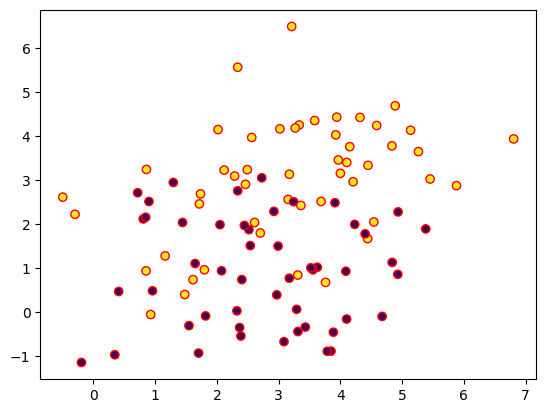

In [2]:
seed = 42

rng = np.random.RandomState(seed)
tf.random.set_seed(seed)

# Generate classification data as a set of points and their labels.
x, y = make_classification(
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=seed,
    n_clusters_per_class=1,
)

# Add random uniform noise
x += 4 * rng.uniform(size=x.shape)

print("Input(X) shape: ", x.shape)
print("Labels(Y) shape: ", y.shape)

plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors="r")

### Train model and generate predictions

Model: Logistic Regression classifier. Logistic regression is equivalent to a one-layer neural network with sigmoid activation.
Activation: Sigmoid activation, so the model prediction will be the prediction probability of class 1.
Loss: Binary Cross Entropy Loss
Optimiser: Stochastic Gradient Descent

It is worth mentioning that tf.keras provides a mechanism for training, hence it is not needed to create any special classes to fit the model and make predictions.

Use `train_test_split` from scikit-learn library to easily divide th data into train and test subsets. 

In [3]:
def logistic_regression(input: tf.Tensor):
    print(input.shape)
    model = Sequential()
    # model.add(Input(shape=(input.shape[0],)))
    # model.add(Dense(1, activation="sigmoid"))
    model.add(Dense(1, activation="sigmoid", input_dim=input.shape[1]))
    return model

In [4]:
# Prepare train and test data
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=seed
)

x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
x_test = tf.convert_to_tensor(x_test, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)

In [6]:
model = logistic_regression(x_train)
optimiser = SGD(learning_rate=0.01)

model.compile(optimizer=optimiser, loss="binary_crossentropy", metrics=["accuracy"])
model.fit(x=x_train, y=y_train, epochs=100)

y_predictions = model.predict(x_test)

(75, 2)
Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4800 - loss: 2.2284  
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4800 - loss: 2.0751 
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4800 - loss: 1.9255 
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4800 - loss: 1.7804 
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4800 - loss: 1.6406 
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4800 - loss: 1.5070 
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4800 - loss: 1.3806 
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4800 - loss: 1.2627 
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4667 - loss: 1.1542 
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4800 - loss: 1.0559 
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4533 - loss: 0.9684 
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4

## Confusion Matrix

In [9]:
def get_tp_tn_fp_fn(y_true, y_predicted, threshold_probability=0.5):
    tp = keras.metrics.TruePositives(
        thresholds=threshold_probability, name=None, dtype=None
    )
    tp.update_state(y_true, y_predicted)

    tn = keras.metrics.TrueNegatives(
        thresholds=threshold_probability, name=None, dtype=None
    )
    tn.update_state(y_true, y_predicted)

    fp = keras.metrics.FalsePositives(
        thresholds=threshold_probability, name=None, dtype=None
    )
    fp.update_state(y_true, y_predicted)

    fn = keras.metrics.FalseNegatives(
        thresholds=threshold_probability, name=None, dtype=None
    )
    fn.update_state(y_true, y_predicted)

    return (
        tp.result().numpy(),
        tn.result().numpy(),
        fp.result().numpy(),
        fn.result().numpy(),
    )

In [16]:
def confusion_metrix(tp, tn, fp, fn):
    conf_matrix = np.array([[tp, fp], [fn, tn]])

    numPositive = tp + fp
    numNegative = fn + tn

    conf_matrix_normalised = np.array(
        [[tp / numPositive, fp / numPositive], [fn / numNegative, tn / numNegative]]
    )

    return conf_matrix, conf_matrix_normalised

In [13]:
def plot_conf_matrix(conf_matrix_normalised):
    plt.figure(figsize=[12, 5])
    sn.heatmap(conf_matrix_normalised, annot=True, annot_kws={"size": 16})
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.show()

Confusion Matrix for threshold probability 0.4


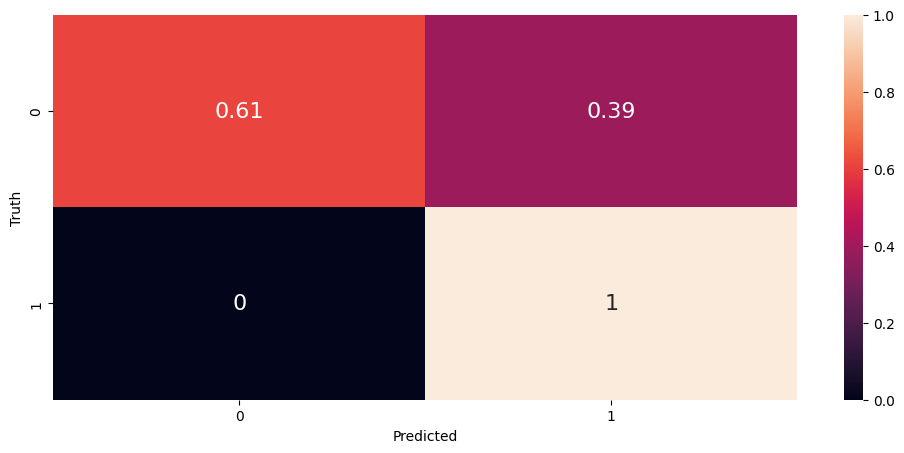

In [18]:
tp, tn, fp, fn = get_tp_tn_fp_fn(y_test, y_predictions, threshold_probability=0.4)
conf_matrix, conf_matrix_normalised = confusion_metrix(tp, tn, fp, fn)
print("Confusion Matrix for threshold probability 0.4")
plot_conf_matrix(conf_matrix_normalised)

Confusion Matrix for threshold probability 0.5


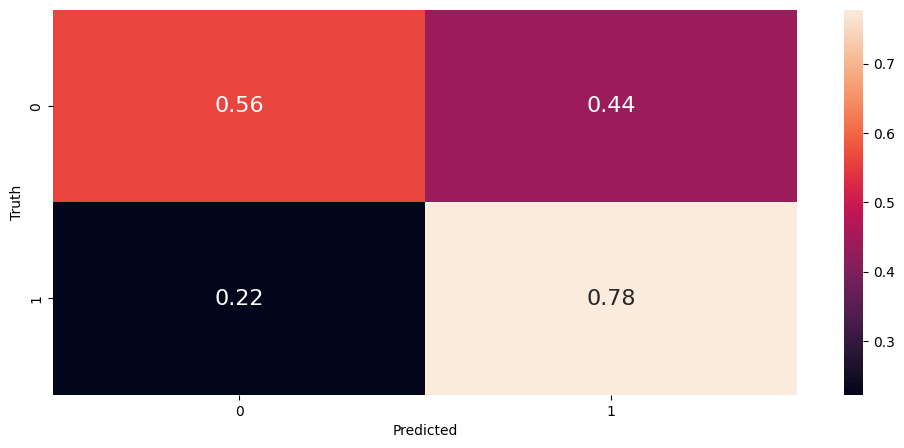

In [20]:
tp, tn, fp, fn = get_tp_tn_fp_fn(y_test, y_predictions, threshold_probability=0.5)
conf_matrix, conf_matrix_normalised = confusion_metrix(tp, tn, fp, fn)
print("Confusion Matrix for threshold probability 0.5")
plot_conf_matrix(conf_matrix_normalised)

Confusion Matrix for threshold probability 0.6


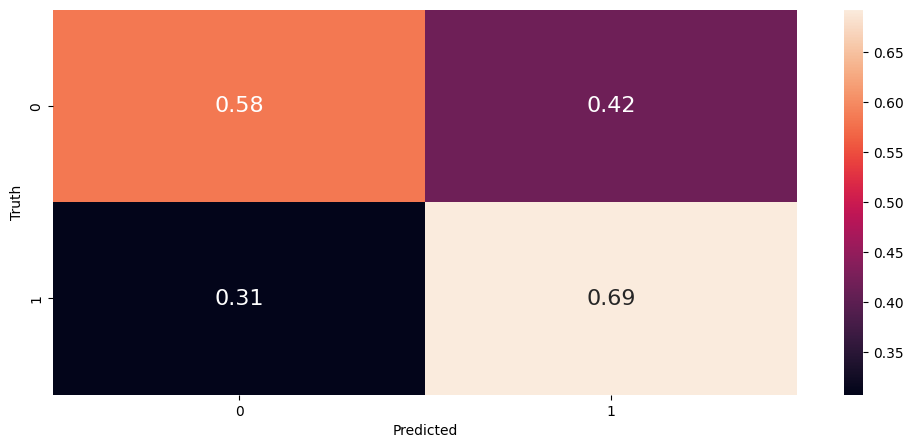

In [22]:
tp, tn, fp, fn = get_tp_tn_fp_fn(y_test, y_predictions, threshold_probability=0.6)
conf_matrix, conf_matrix_normalised = confusion_metrix(tp, tn, fp, fn)
print("Confusion Matrix for threshold probability 0.6")
plot_conf_matrix(conf_matrix_normalised)

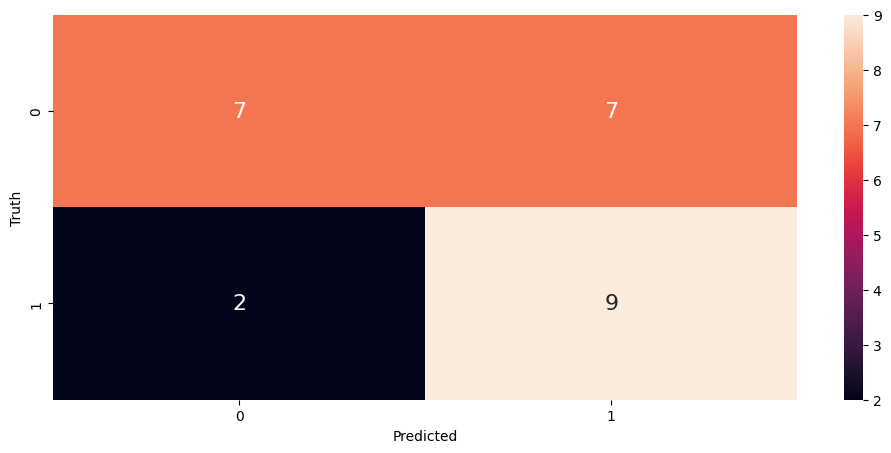

In [33]:
# Confusion Matrix provided by TensorFlow
predictions = tf.cast(y_predictions > 0.5, dtype=tf.float32)

cm = tf.math.confusion_matrix(y_test, predictions)
plot_conf_matrix(cm)

## Accuracy

In [35]:
preds = tf.cast(y_predictions >= 0.5, dtype=tf.float32)
accuracy = tf.keras.metrics.binary_accuracy(
    tf.expand_dims(y_test, 1), y_predictions, threshold=0.5
)
print(f"Accuracy at threshold 0.5: {tf.reduce_mean(accuracy).numpy()}")

Accuracy at threshold 0.5: 0.6399999856948853


## Precision

In [36]:
threshold = 0.5
precision = tf.keras.metrics.Precision(thresholds=threshold)
precision.update_state(y_test, y_predictions)
print(f"Precision at threhold 0.5: {precision.result().numpy()}")

Precision at threhold 0.5: 0.5625


## Recall

In [37]:
threshold = 0.5
precision = tf.keras.metrics.Recall(thresholds=threshold)
precision.update_state(y_test, y_predictions)
print(f"Recall at threhold 0.5: {precision.result().numpy()}")

Recall at threhold 0.5: 0.8181818127632141


## F1 Score

In [42]:
thres_prob = 0.5
predictions = y_predictions > thres_prob
tp, tn, fp, fn = get_tp_tn_fp_fn(y_test, y_predictions, thres_prob)
f1_score = (2 * tp) / (2 * tp + fp + fn)
print(f"F1-Score at threhold 0.5: {f1_score}")

F1-Score at threhold 0.5: 0.6666666865348816


## ROC Curve using Confusion Matrix

In [41]:
thresholds = np.linspace(0.001, 0.999, 1000)
len(thresholds)

auc = tf.keras.metrics.AUC(thresholds=thresholds)
auc.update_state(y_test, y_predictions)
print(f"AUC: {auc.result().numpy()}")

AUC: 0.7694805264472961


In [50]:
tpr_list, fpr_list = [], []
for threshold in thresholds:
    # get TP, FP, FN, and TN to calculate TPR and FPR
    tp, tn, fp, fn = get_tp_tn_fp_fn(y_test, y_predictions, threshold)

    # Sensitivity, recall, or true positive rate
    tpr = tp / (tp + fn)
    tpr_list.append(tpr)

    # False positive rate
    fpr = fp / (fp + tn)
    fpr_list.append(fpr)
# print(tpr_list)
# print(fpr_list)

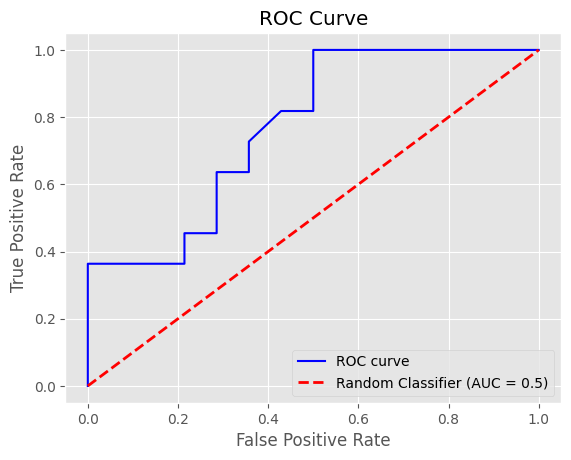

In [53]:
plt.plot(fpr_list, tpr_list, label="ROC curve", color="b")
plt.plot(
    [0, 1],
    [0, 1],
    label="Random Classifier (AUC = 0.5)",
    linestyle="--",
    lw=2,
    color="r",
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.title("ROC Curve")
plt.grid(True)
plt.show(block=False)